# LET'S GOOOOOOOOOOOOOOOOOOOO

In [2]:
!pip install rtdl_revisiting_models

In [3]:
!pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.7 MB/s eta 0:00:00


In [4]:
import os
import json
import copy
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

import torch
import torch.nn as nn
from pytorch_tabnet.tab_model import TabNetClassifier
from rtdl_revisiting_models import FTTransformer


In [ ]:
BASE_DIR = "/content/drive/MyDrive/[02] University/S7/Pembelajaran Mesin/UAP"

In [5]:
df = pd.read_csv("/content/weather_classification_data.csv")

df.head(), df.shape, df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


(   Temperature  Humidity  Wind Speed  Precipitation (%)    Cloud Cover  \
 0         14.0        73         9.5               82.0  partly cloudy   
 1         39.0        96         8.5               71.0  partly cloudy   
 2         30.0        64         7.0               16.0          clear   
 3         38.0        83         1.5               82.0          clear   
 4         27.0        74        17.0               66.0       overcast   
 
    Atmospheric Pressure  UV Index  Season  Visibility (km)  Location  \
 0               1010.82         2  Winter              3.5    inland   
 1               1011.43         7  Spring             10.0    inland   
 2               1018.72         5  Spring              5.5  mountain   
 3               1026.25         7  Spring              1.0   coastal   
 4                990.67         1  Winter              2.5  mountain   
 
   Weather Type  
 0        Rainy  
 1       Cloudy  
 2        Sunny  
 3        Sunny  
 4        Rainy  ,

In [6]:
df.isnull().sum()

,0
Temperature,0
Humidity,0
Wind Speed,0
Precipitation (%),0
Cloud Cover,0
Atmospheric Pressure,0
UV Index,0
Season,0
Visibility (km),0
Location,0


In [7]:
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


In [9]:
df['Weather Type'].value_counts()

,count
Weather Type,
Rainy,3300
Cloudy,3300
Sunny,3300
Snowy,3300


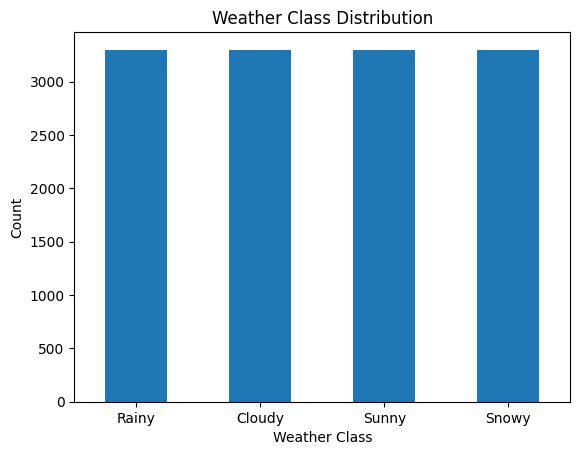

In [10]:
df['Weather Type'].value_counts().plot(kind='bar')
plt.title("Weather Class Distribution")
plt.xlabel("Weather Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [11]:
target = "Weather Type"

num_cols = df.drop(columns=[target]).select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

cat_cols = df.drop(columns=[target]).select_dtypes(
    include=["object", "category"]
).columns.tolist()

label_encoder = LabelEncoder()
df[target] = label_encoder.fit_transform(df[target])

class_names = label_encoder.classes_.tolist()
num_classes = len(class_names)

X = df[num_cols + cat_cols]
y = df[target]


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)


In [ ]:
X_train_mlp, X_val_mlp, X_test_mlp = X_train.copy(), X_val.copy(), X_test.copy()
X_train_tab, X_val_tab, X_test_tab = X_train.copy(), X_val.copy(), X_test.copy()
X_train_ft,  X_val_ft,  X_test_ft  = X_train.copy(), X_val.copy(), X_test.copy()


# 🔵 MLP MODEL

In [ ]:
mlp_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

X_train_mlp_p = mlp_preprocessor.fit_transform(X_train_mlp)
X_val_mlp_p   = mlp_preprocessor.transform(X_val_mlp)
X_test_mlp_p  = mlp_preprocessor.transform(X_test_mlp)


In [ ]:
mlp = models.Sequential([
    layers.Dense(128, activation="relu", input_shape=(X_train_mlp_p.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

mlp.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_mlp = mlp.fit(
    X_train_mlp_p, y_train,
    validation_data=(X_val_mlp_p, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7613 - loss: 0.6816 - val_accuracy: 0.8894 - val_loss: 0.2940
Epoch 2/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9041 - loss: 0.2731 - val_accuracy: 0.9091 - val_loss: 0.2445
Epoch 3/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9115 - loss: 0.2283 - val_accuracy: 0.9096 - val_loss: 0.2275
Epoch 4/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9161 - loss: 0.2121 - val_accuracy: 0.9146 - val_loss: 0.2133
Epoch 5/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9108 - loss: 0.2072 - val_accuracy: 0.9146 - val_loss: 0.2084
Epoch 6/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9235 - loss: 0.1848 - val_accuracy: 0.9167 - val_loss: 0.2053
Epoch 7/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9198 - loss: 0.1885 - val_accuracy: 0.9141 - val_loss: 0.1993
Epoch 8/50
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9221 - loss: 0.1817 - val_accuracy: 0.

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
MLP Classification Report
              precision    recall  f1-score   support

      Cloudy       0.87      0.91      0.89       495
       Rainy       0.90      0.90      0.90       495
       Snowy       0.92      0.93      0.93       495
       Sunny       0.95      0.90      0.92       495

    accuracy                           0.91      1980
   macro avg       0.91      0.91      0.91      1980
weighted avg       0.91      0.91      0.91      1980



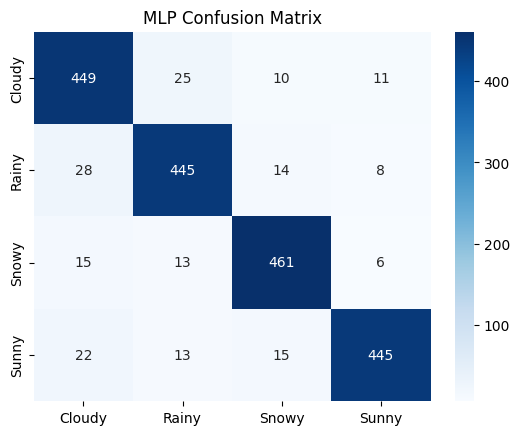

In [ ]:
y_pred_mlp = np.argmax(mlp.predict(X_test_mlp_p), axis=1)

print("MLP Classification Report")
print(classification_report(y_test, y_pred_mlp, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.title("MLP Confusion Matrix")
plt.show()


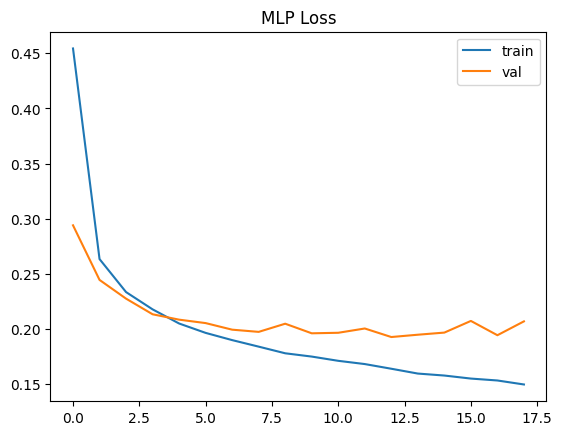

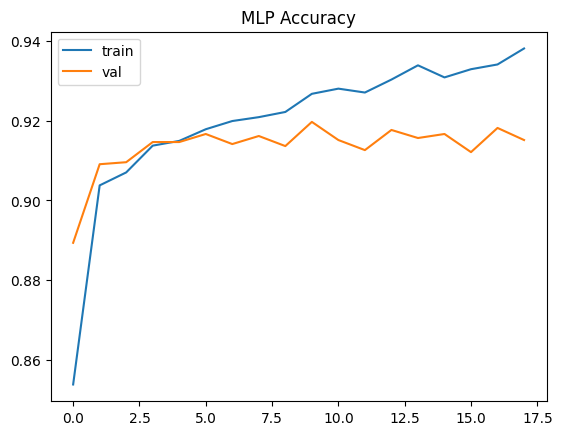

In [ ]:
plt.plot(history_mlp.history["loss"], label="train")
plt.plot(history_mlp.history["val_loss"], label="val")
plt.title("MLP Loss")
plt.legend()
plt.show()

plt.plot(history_mlp.history["accuracy"], label="train")
plt.plot(history_mlp.history["val_accuracy"], label="val")
plt.title("MLP Accuracy")
plt.legend()
plt.show()


# 🟠 TABNET MODEL

In [ ]:
tab_encoders = {}

for col in cat_cols:
    le_tab = LabelEncoder()
    X_train_tab[col] = le_tab.fit_transform(X_train_tab[col])
    X_val_tab[col]   = le_tab.transform(X_val_tab[col])
    X_test_tab[col]  = le_tab.transform(X_test_tab[col])
    tab_encoders[col] = le_tab

X_train_tab_v = X_train_tab[num_cols + cat_cols].values
X_val_tab_v   = X_val_tab[num_cols + cat_cols].values
X_test_tab_v  = X_test_tab[num_cols + cat_cols].values


In [ ]:
tabnet = TabNetClassifier(
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    n_d=32, n_a=32,
    n_steps=5,
    gamma=1.5,
    verbose=1
)

tabnet.fit(
    X_train_tab_v, y_train.values,
    eval_set=[
        (X_train_tab_v, y_train.values),
        (X_val_tab_v, y_val.values)
    ],
    eval_name=["train", "valid"],
    eval_metric=["accuracy", "logloss"],
    max_epochs=50,
    patience=10,
    batch_size=256
)



/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.8405  | train_accuracy: 0.37457 | train_logloss: 5.16749 | valid_accuracy: 0.36667 | valid_logloss: 5.16378 |  0:00:02s
epoch 1  | loss: 0.44739 | train_accuracy: 0.26591 | train_logloss: 4.37942 | valid_accuracy: 0.26919 | valid_logloss: 4.39888 |  0:00:05s
epoch 2  | loss: 0.39467 | train_accuracy: 0.33019 | train_logloss: 3.78534 | valid_accuracy: 0.32172 | valid_logloss: 3.65597 |  0:00:07s
epoch 3  | loss: 0.35142 | train_accuracy: 0.54426 | train_logloss: 1.12979 | valid_accuracy: 0.53687 | valid_logloss: 1.16643 |  0:00:09s
epoch 4  | loss: 0.31248 | train_accuracy: 0.575   | train_logloss: 1.25885 | valid_accuracy: 0.57121 | valid_logloss: 1.28766 |  0:00:11s
epoch 5  | loss: 0.27667 | train_accuracy: 0.70357 | train_logloss: 0.8286  | valid_accuracy: 0.70051 | valid_logloss: 0.85484 |  0:00:13s
epoch 6  | loss: 0.27966 | train_accuracy: 0.48214 | train_logloss: 1.05756 | valid_accuracy: 0.49293 | valid_logloss: 1.05781 |  0:00:15s
epoch 7  | loss: 0.26913 | 

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


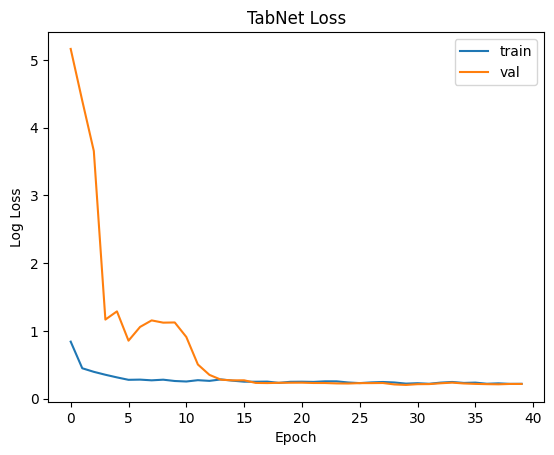

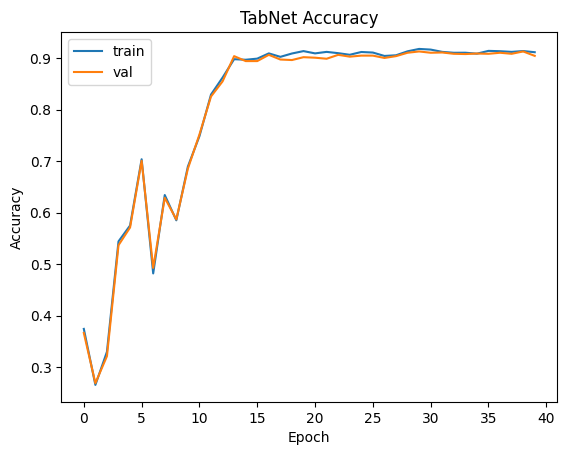

In [ ]:
plt.plot(tabnet.history["loss"], label="train")
plt.plot(tabnet.history["valid_logloss"], label="val")
plt.title("TabNet Loss")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

plt.plot(tabnet.history["train_accuracy"], label="train")
plt.plot(tabnet.history["valid_accuracy"], label="val")
plt.title("TabNet Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [ ]:
y_pred_tab = tabnet.predict(X_test_tab_v)

print("TabNet Classification Report")

report = classification_report(
    y_test,
    y_pred_tab,
    labels=np.unique(y_test),
    target_names=[class_names[i] for i in np.unique(y_test)]
)

print(report)

TabNet Classification Report
              precision    recall  f1-score   support

      Cloudy       0.83      0.93      0.88       495
       Rainy       0.91      0.89      0.90       495
       Snowy       0.96      0.91      0.93       495
       Sunny       0.93      0.88      0.91       495

    accuracy                           0.90      1980
   macro avg       0.91      0.90      0.90      1980
weighted avg       0.91      0.90      0.90      1980



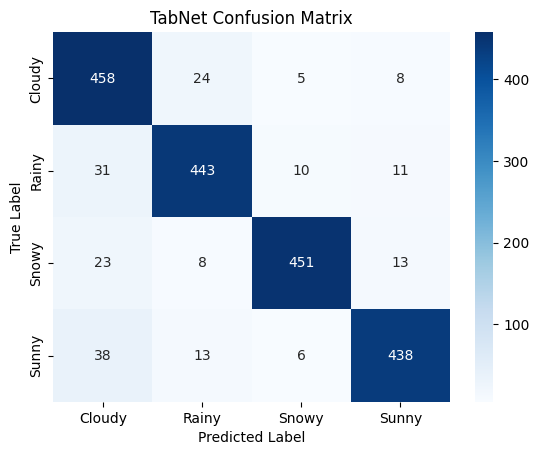

In [ ]:
labels = np.unique(y_test)

cm = confusion_matrix(
    y_test,
    y_pred_tab,
    labels=labels
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[class_names[i] for i in labels],
    yticklabels=[class_names[i] for i in labels]
)

plt.title("TabNet Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


# 🔴 FT-TRANSFORMER MODEL

In [ ]:
cat_encoders = {}
for col in cat_cols:
    le_cat = LabelEncoder()
    X_train_ft[col] = le_cat.fit_transform(X_train_ft[col])
    X_val_ft[col]   = le_cat.transform(X_val_ft[col])
    X_test_ft[col]  = le_cat.transform(X_test_ft[col])
    cat_encoders[col] = le_cat

scaler = StandardScaler()
X_train_ft[num_cols] = scaler.fit_transform(X_train_ft[num_cols])
X_val_ft[num_cols]   = scaler.transform(X_val_ft[num_cols])
X_test_ft[num_cols]  = scaler.transform(X_test_ft[num_cols])


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

X_train_num = torch.tensor(X_train_ft[num_cols].values, dtype=torch.float32).to(device)
X_val_num   = torch.tensor(X_val_ft[num_cols].values,   dtype=torch.float32).to(device)
X_test_num  = torch.tensor(X_test_ft[num_cols].values,  dtype=torch.float32).to(device)

X_train_cat = torch.tensor(X_train_ft[cat_cols].values, dtype=torch.long).to(device)
X_val_cat   = torch.tensor(X_val_ft[cat_cols].values,   dtype=torch.long).to(device)
X_test_cat  = torch.tensor(X_test_ft[cat_cols].values,  dtype=torch.long).to(device)

y_train_t = torch.tensor(y_train.values, dtype=torch.long).to(device)
y_val_t   = torch.tensor(y_val.values,   dtype=torch.long).to(device)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.long).to(device)

cat_cardinalities = [
    len(cat_encoders[col].classes_) for col in cat_cols
]

model = FTTransformer(
    n_cont_features=len(num_cols),
    cat_cardinalities=cat_cardinalities,

    d_block=32,
    n_blocks=4,
    attention_n_heads=8,

    attention_dropout=0.1,
    ffn_d_hidden_multiplier=4 / 3,
    ffn_dropout=0.1,
    residual_dropout=0.1,

    d_out=num_classes
).to(device)



In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

criterion = nn.CrossEntropyLoss()


In [ ]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_state = None
best_val_loss = float("inf")
patience = 7
counter = 0

for epoch in range(500):
    # ===== TRAIN =====
    model.train()
    optimizer.zero_grad()

    out = model(X_train_num, X_train_cat)
    loss = criterion(out, y_train_t)
    loss.backward()
    optimizer.step()

    train_preds = out.argmax(dim=1)
    train_acc = (train_preds == y_train_t).float().mean().item()

    # ===== VALID =====
    model.eval()
    with torch.no_grad():
        val_out = model(X_val_num, X_val_cat)
        val_loss = criterion(val_out, y_val_t)

        val_preds = val_out.argmax(dim=1)
        val_acc = (val_preds == y_val_t).float().mean().item()

    # ===== TRACK =====
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # ===== EARLY STOP =====
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_state = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss {loss.item():.4f} | Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss.item():.4f} | Val Acc {val_acc:.4f}"
    )

    if counter >= patience:
        print("Early stopping triggered")
        break

model.load_state_dict(best_state)
model.eval()


Epoch 01 | Train Loss 1.4741 | Train Acc 0.2058 | Val Loss 1.3782 | Val Acc 0.3242
Epoch 02 | Train Loss 1.3928 | Train Acc 0.2890 | Val Loss 1.3471 | Val Acc 0.3576
Epoch 03 | Train Loss 1.3638 | Train Acc 0.3171 | Val Loss 1.3155 | Val Acc 0.3818
Epoch 04 | Train Loss 1.3367 | Train Acc 0.3459 | Val Loss 1.2818 | Val Acc 0.4106
Epoch 05 | Train Loss 1.3066 | Train Acc 0.3782 | Val Loss 1.2418 | Val Acc 0.4667
Epoch 06 | Train Loss 1.2676 | Train Acc 0.4424 | Val Loss 1.1975 | Val Acc 0.5439
Epoch 07 | Train Loss 1.2301 | Train Acc 0.4864 | Val Loss 1.1527 | Val Acc 0.5742
Epoch 08 | Train Loss 1.1868 | Train Acc 0.5301 | Val Loss 1.1102 | Val Acc 0.5778
Epoch 09 | Train Loss 1.1458 | Train Acc 0.5601 | Val Loss 1.0751 | Val Acc 0.5778
Epoch 10 | Train Loss 1.1094 | Train Acc 0.5814 | Val Loss 1.0464 | Val Acc 0.5828
Epoch 11 | Train Loss 1.0796 | Train Acc 0.6104 | Val Loss 1.0182 | Val Acc 0.6460
Epoch 12 | Train Loss 1.0499 | Train Acc 0.6395 | Val Loss 0.9884 | Val Acc 0.7470
Epoc

FTTransformer(
  (cls_embedding): _CLSEmbedding()
  (cont_embeddings): LinearEmbeddings()
  (cat_embeddings): CategoricalEmbeddings(
    (embeddings): ModuleList(
      (0-1): 2 x Embedding(4, 32)
      (2): Embedding(3, 32)
    )
  )
  (backbone): FTTransformerBackbone(
    (blocks): ModuleList(
      (0): ModuleDict(
        (attention): MultiheadAttention(
          (W_q): Linear(in_features=32, out_features=32, bias=True)
          (W_k): Linear(in_features=32, out_features=32, bias=True)
          (W_v): Linear(in_features=32, out_features=32, bias=True)
          (W_out): Linear(in_features=32, out_features=32, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (attention_residual_dropout): Dropout(p=0.1, inplace=False)
        (ffn_normalization): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (ffn): Sequential(
          (linear1): Linear(in_features=32, out_features=84, bias=True)
          (activation): _ReGLU()
          (dropout): 

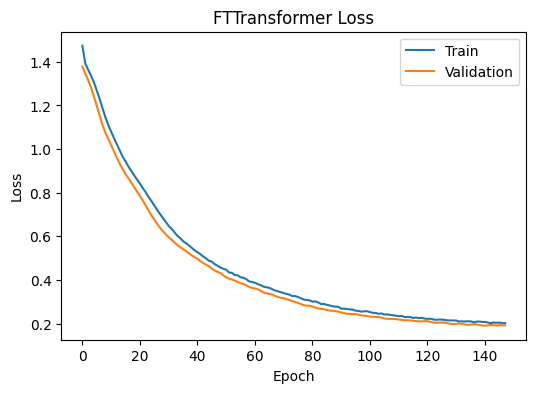

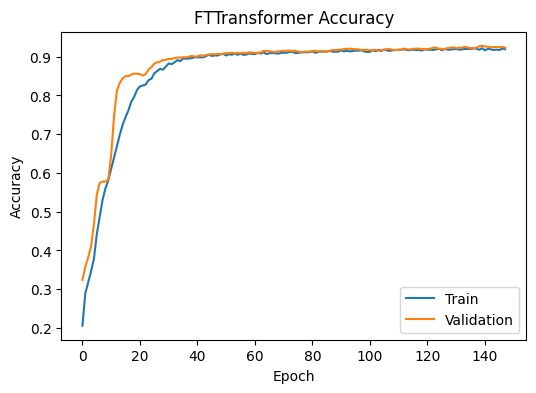

In [ ]:
# ===== LOSS =====
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.title("FTTransformer Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# ===== ACCURACY =====
plt.figure(figsize=(6, 4))
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Validation")
plt.title("FTTransformer Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [ ]:
with torch.no_grad():
    y_pred_ft = model(X_test_num, X_test_cat).argmax(1).cpu().numpy()

labels = np.unique(y_test)

print("FTTransformer Classification Report")
print(
    classification_report(
        y_test,
        y_pred_ft,
        labels=labels,
        target_names=[class_names[i] for i in labels]
    )
)


FTTransformer Classification Report
              precision    recall  f1-score   support

      Cloudy       0.85      0.91      0.88       495
       Rainy       0.88      0.90      0.89       495
       Snowy       0.94      0.92      0.93       495
       Sunny       0.95      0.89      0.92       495

    accuracy                           0.90      1980
   macro avg       0.91      0.90      0.90      1980
weighted avg       0.91      0.90      0.90      1980



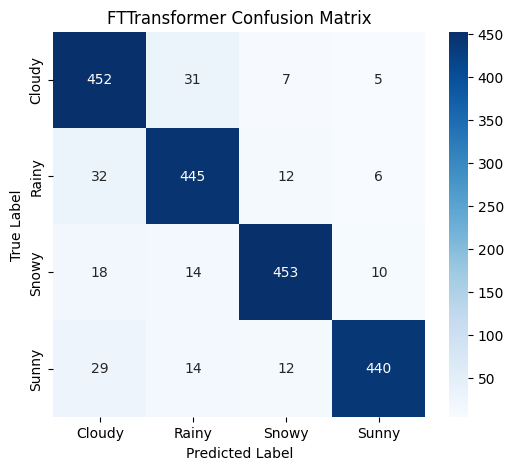

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred_ft,
    labels=labels
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[class_names[i] for i in labels],
    yticklabels=[class_names[i] for i in labels]
)

plt.title("FTTransformer Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [ ]:
# =========================
# Imports
# =========================
import os
import joblib
import torch

# =========================
# Create artifact folders
# =========================
os.makedirs(f"{BASE_DIR}/artifacts/mlp", exist_ok=True)
os.makedirs(f"{BASE_DIR}/artifacts/tabnet", exist_ok=True)
os.makedirs(f"{BASE_DIR}/artifacts/ft_transformer", exist_ok=True)

# =========================
# 1️⃣ SAVE MLP (Keras)
# =========================
mlp.save(
    f"{BASE_DIR}/artifacts/mlp/model.keras"
)

joblib.dump(
    mlp_preprocessor,
    f"{BASE_DIR}/artifacts/mlp/preprocessor.joblib"
)

joblib.dump(
    label_encoder,
    f"{BASE_DIR}/artifacts/mlp/label_encoder.joblib"
)

joblib.dump(num_cols, f"{BASE_DIR}/artifacts/mlp/num_cols.joblib")
joblib.dump(cat_cols, f"{BASE_DIR}/artifacts/mlp/cat_cols.joblib")


# =========================
# 2️⃣ SAVE TABNET
# =========================
tabnet.save_model(
    f"{BASE_DIR}/artifacts/tabnet/tabnet_model"
)

joblib.dump(
    tab_encoders,
    f"{BASE_DIR}/artifacts/tabnet/cat_encoders.joblib"
)

joblib.dump(
    label_encoder,
    f"{BASE_DIR}/artifacts/tabnet/label_encoder.joblib"
)

joblib.dump(
    num_cols,
    f"{BASE_DIR}/artifacts/tabnet/num_cols.joblib"
)

joblib.dump(
    cat_cols,
    f"{BASE_DIR}/artifacts/tabnet/cat_cols.joblib"
)

# =========================
# 3️⃣ SAVE FTTRANSFORMER
# =========================
torch.save(
    {
        "model_state_dict": best_state,
        "cat_encoders": cat_encoders,
        "scaler": scaler,
        "label_encoder": label_encoder,
        "class_names": label_encoder.classes_.tolist(),
        "cat_cols": cat_cols,
        "num_cols": num_cols,
        "num_classes": num_classes,

        # Architecture (for safe reload)
        "d_block": 32,
        "n_blocks": 4,
        "attention_n_heads": 8,
        "attention_dropout": 0.1,
        "ffn_d_hidden_multiplier": 4 / 3,
        "ffn_dropout": 0.1,
        "residual_dropout": 0.1,
    },
    f"{BASE_DIR}/artifacts/ft_transformer/model.pt"
)

print("✅ All models and preprocessors saved successfully")


Successfully saved model at /content/drive/MyDrive/[02] University/S7/Pembelajaran Mesin/UAP/artifacts/tabnet/tabnet_model.zip
✅ All models and preprocessors saved successfully
